# Protein Q3 (CullPDB → CB513): CNN + BiLSTM dengan bobot kelas & pemantauan macro-F1

Notebook ini mengatasi kekurangan baseline **Protein_1D_Q3.ipynb**:

1. **Imbalance Q3** — `sample_weight` = mask × bobot kelas **balanced** (dari frekuensi residu valid di train).
2. **Konteks urutan** — lapisan **Bidirectional LSTM** setelah Conv1D (bukan hanya `TimeDistributed(Dense)`).
3. **Metrik selaras tujuan** — simpan bobot terbaik menurut **macro-F1 pada val** (bukan hanya `val_accuracy`).
4. **Evaluasi** — akurasi bermasker di CB513 + precision/recall/F1 macro + AUC OVR + *balanced accuracy*.

Pemisahan data sama: latih/val **CullPDB**, uji **CB513**; fitur **54 kanal** (AA + profil), label **Q3** di kanal 21–24 tidak dimasukkan ke `X`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Path data

- **Google Colab:** pasang Drive lalu set `BASE_DIR` ke folder berisi `.npy.gz`.
- **Lokal:** set `BASE_DIR` ke path absolut folder dataset Anda.

In [2]:
# Uncomment jika memakai Colab:
# from google.colab import drive
# drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/Raw Dataset"  # sesuaikan

import os
import numpy as np

for name in ("cb513+profile_split1.npy.gz", "cullpdb+profile_5926_filtered.npy.gz"):
    p = os.path.join(BASE_DIR, name)
    if not os.path.isfile(p):
        raise FileNotFoundError(f"Missing: {p}")

cb513 = np.load(os.path.join(BASE_DIR, "cb513+profile_split1.npy.gz"), allow_pickle=True)
cullpdb = np.load(os.path.join(BASE_DIR, "cullpdb+profile_5926_filtered.npy.gz"), allow_pickle=True)

cb513 = cb513.reshape(cb513.shape[0], 700, 57)
cullpdb = cullpdb.reshape(cullpdb.shape[0], 700, 57)
print("cb513:", cb513.shape, "cullpdb:", cullpdb.shape)

/tmp/ipykernel_4711/4200680897.py:15: UserWarning: Reading `.npy` or `.npz` file required additional header parsing as it was created on Python 2. Save the file again to speed up loading and avoid this warning.
  cb513 = np.load(os.path.join(BASE_DIR, "cb513+profile_split1.npy.gz"), allow_pickle=True)


cb513: (514, 700, 57) cullpdb: (5365, 700, 57)


In [3]:
def extract(dataset):
    y = dataset[:, :, 21:24]
    X_aa = dataset[:, :, :21]
    X_other = dataset[:, :, 24:]
    X = np.concatenate([X_aa, X_other], axis=2)
    mask = np.sum(X, axis=2) != 0
    return X.astype(np.float32), y.astype(np.float32), mask


np.random.seed(42)
n_samples = cullpdb.shape[0]
indices = np.random.permutation(n_samples)
split = int(0.8 * n_samples)
train_idx, val_idx = indices[:split], indices[split:]

dataset_train = cullpdb[train_idx]
dataset_val = cullpdb[val_idx]
dataset_test = cb513

X_train, y_train, mask_train = extract(dataset_train)
X_val, y_val, mask_val = extract(dataset_val)
X_test, y_test, mask_test = extract(dataset_test)

N_CLASSES = 3
print("X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)

X_train (4292, 700, 54) X_val (1073, 700, 54) X_test (514, 700, 54)


In [4]:
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = np.argmax(y_train, axis=-1)
flat_labels = y_train_labels[mask_train]
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(N_CLASSES),
    y=flat_labels,
)
print("Class weights (balanced):", class_weights)

sw_train = mask_train.astype(np.float32) * class_weights[y_train_labels]
y_val_labels = np.argmax(y_val, axis=-1)
sw_val = mask_val.astype(np.float32) * class_weights[y_val_labels]

Class weights (balanced): [  0.35540691   5.65359588 105.87447581]


In [5]:
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv1D, Dropout, Bidirectional, LSTM, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


def build_model(dropout=0.35, lstm_units=64):
    inp = Input(shape=(700, 54))
    x = Conv1D(96, 5, padding="same", activation="relu")(inp)
    x = Conv1D(128, 5, padding="same", activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Bidirectional(LSTM(lstm_units, return_sequences=True))(x)
    x = Dropout(dropout)(x)
    x = TimeDistributed(Dense(64, activation="relu"))(x)
    out = TimeDistributed(Dense(N_CLASSES, activation="softmax"))(x)
    return Model(inp, out)


model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 700, 54)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 700, 96)        │        26,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 700, 128)       │        61,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 700, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 700, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 700, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 700, 64)        │         8,256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 700, 3)         │           195 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194,851 (761.14 KB)

 Trainable params: 194,851 (761.14 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from sklearn.metrics import f1_score


def macro_f1_masked(y_true, y_pred_prob, mask):
    m = mask.astype(bool).reshape(-1)
    yt = np.argmax(y_true.reshape(-1, N_CLASSES)[m], axis=1)
    yp = np.argmax(y_pred_prob.reshape(-1, N_CLASSES)[m], axis=1)
    return float(f1_score(yt, yp, average="macro", zero_division=0))


class ValMacroF1Checkpoint(tf.keras.callbacks.Callback):
    """Log val_macro_f1; simpan bobot terbaik menurut macro-F1 (val)."""

    def __init__(self, X_val, y_val, mask_val, filepath, **kwargs):
        super().__init__(**kwargs)
        self.X_val = X_val
        self.y_val = y_val
        self.mask_val = mask_val
        self.filepath = filepath
        self.best = -1.0

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        pred = self.model.predict(self.X_val, batch_size=32, verbose=0)
        f1 = macro_f1_masked(self.y_val, pred, self.mask_val)
        logs["val_macro_f1"] = f1
        print(f" end epoch {epoch + 1}: val_macro_f1={f1:.4f}")
        if f1 > self.best:
            self.best = f1
            self.model.save_weights(self.filepath)
            print(f"  saved best weights ({f1:.4f}) -> {self.filepath}")


WEIGHTS_PATH = "best_q3_macrof1.weights.h5"
cb_f1 = ValMacroF1Checkpoint(X_val, y_val, mask_val, WEIGHTS_PATH)
cb_es = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=False,
)
cb_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1,
)

history = model.fit(
    X_train,
    y_train,
    sample_weight=sw_train,
    validation_data=(X_val, y_val, sw_val),
    epochs=40,
    batch_size=16,
    callbacks=[cb_f1, cb_es, cb_lr],
    verbose=1,
)

model.load_weights(WEIGHTS_PATH)
print("Loaded weights with best val macro-F1:", cb_f1.best)

Epoch 1/40
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7046 - loss: 0.4845 end epoch 1: val_macro_f1=0.3834
  saved best weights (0.3834) -> best_q3_macrof1.weights.h5
269/269 ━━━━━━━━━━━━━━━━━━━━ 179s 411ms/step - accuracy: 0.7274 - loss: 0.4155 - val_accuracy: 0.7267 - val_loss: 0.3682 - val_macro_f1: 0.3834 - learning_rate: 0.0010
Epoch 2/40
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.7364 - loss: 0.3561 end epoch 2: val_macro_f1=0.4090
  saved best weights (0.4090) -> best_q3_macrof1.weights.h5
269/269 ━━━━━━━━━━━━━━━━━━━━ 65s 242ms/step - accuracy: 0.7366 - loss: 0.3525 - val_accuracy: 0.7414 - val_loss: 0.3424 - val_macro_f1: 0.4090 - learning_rate: 0.0010
Epoch 3/40
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.7393 - loss: 0.3312 end epoch 3: val_macro_f1=0.4113
  saved best weights (0.4113) -> best_q3_macrof1.weights.h5
269/269 ━━━━━━━━━━━━━━━━━━━━ 66s 244ms/step - accuracy: 0.7377 - loss: 0.3287 - val_accuracy: 0.7424 - val_loss: 0.3356 - 

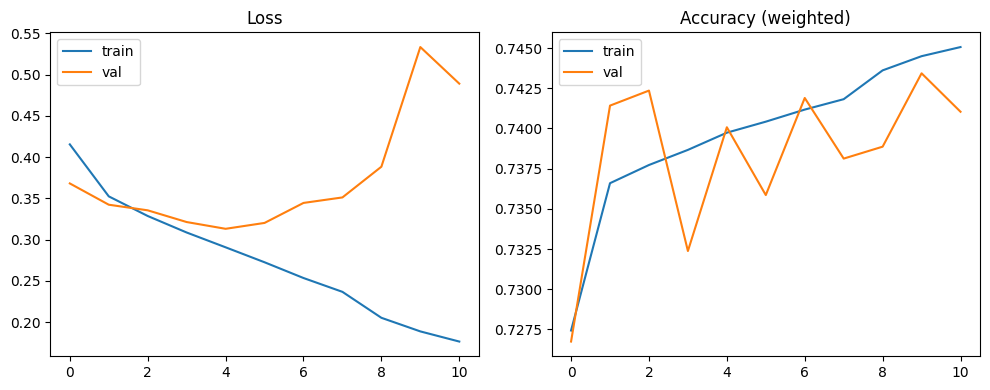

In [7]:
import matplotlib.pyplot as plt

h = history.history
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(h["loss"], label="train")
ax[0].plot(h["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].legend()
ax[1].plot(h["accuracy"], label="train")
ax[1].plot(h["val_accuracy"], label="val")
ax[1].set_title("Accuracy (weighted)")
ax[1].legend()
plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    sample_weight=mask_test.astype(np.float32),
    verbose=1,
)

y_pred = model.predict(X_test, batch_size=32, verbose=0)
m = mask_test.astype(bool).reshape(-1)
y_true_flat = y_test.reshape(-1, N_CLASSES)[m]
y_pred_flat = y_pred.reshape(-1, N_CLASSES)[m]
y_true_label = np.argmax(y_true_flat, axis=1)
y_pred_label = np.argmax(y_pred_flat, axis=1)

acc = accuracy_score(y_true_label, y_pred_label)
bacc = balanced_accuracy_score(y_true_label, y_pred_label)
prec = precision_score(y_true_label, y_pred_label, average="macro", zero_division=0)
rec = recall_score(y_true_label, y_pred_label, average="macro", zero_division=0)
f1m = f1_score(y_true_label, y_pred_label, average="macro", zero_division=0)
auc = roc_auc_score(y_true_flat, y_pred_flat, multi_class="ovr")

print(f"Keras evaluate accuracy (masked): {test_acc:.4f}")
print(f"Sklearn accuracy (masked)        : {acc:.4f}")
print(f"Balanced accuracy               : {bacc:.4f}")
print(f"Precision (macro)               : {prec:.4f}")
print(f"Recall (macro)                  : {rec:.4f}")
print(f"F1 (macro)                      : {f1m:.4f}")
print(f"AUC (OVR)                       : {auc:.4f}")
print("\nClassification report (Helix=0, Sheet=1, Coil=2):")
print(classification_report(y_true_label, y_pred_label, digits=4, zero_division=0))

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.7942 - loss: 0.0417
Keras evaluate accuracy (masked): 0.7942
Sklearn accuracy (masked)        : 0.7942
Balanced accuracy               : 0.7200
Precision (macro)               : 0.4080
Recall (macro)                  : 0.7200
F1 (macro)                      : 0.4117
AUC (OVR)                       : 0.9481

Classification report (Helix=0, Sheet=1, Coil=2):
              precision    recall  f1-score   support

           0     1.0000    0.8073    0.8934    340699
           1     0.1970    0.5442    0.2893     17920
           2     0.0271    0.8086    0.0524      1181

    accuracy                         0.7942    359800
   macro avg     0.4080    0.7200    0.4117    359800
weighted avg     0.9568    0.7942    0.8605    359800

